In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
iris = load_iris()

df= pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].apply(lambda x: iris.target_names[x])

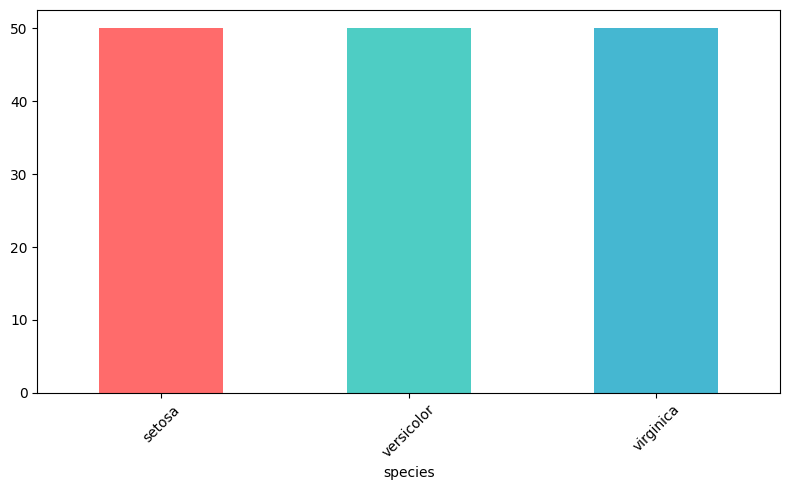

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
(120, 4)
(30, 4)


In [3]:
plt.figure(figsize=(8, 5))
df['species'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df['species'].value_counts())

X = iris.data 
y = iris.target

# 훈련/테스트데이터분리(80% 훈련, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

In [4]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)

accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

print("Information Gain(Entropy) 기준 정확도:", round(accuracy_entropy, 4))
print(f"{accuracy_entropy*100:.2f}%")


Information Gain(Entropy) 기준 정확도: 1.0
100.00%


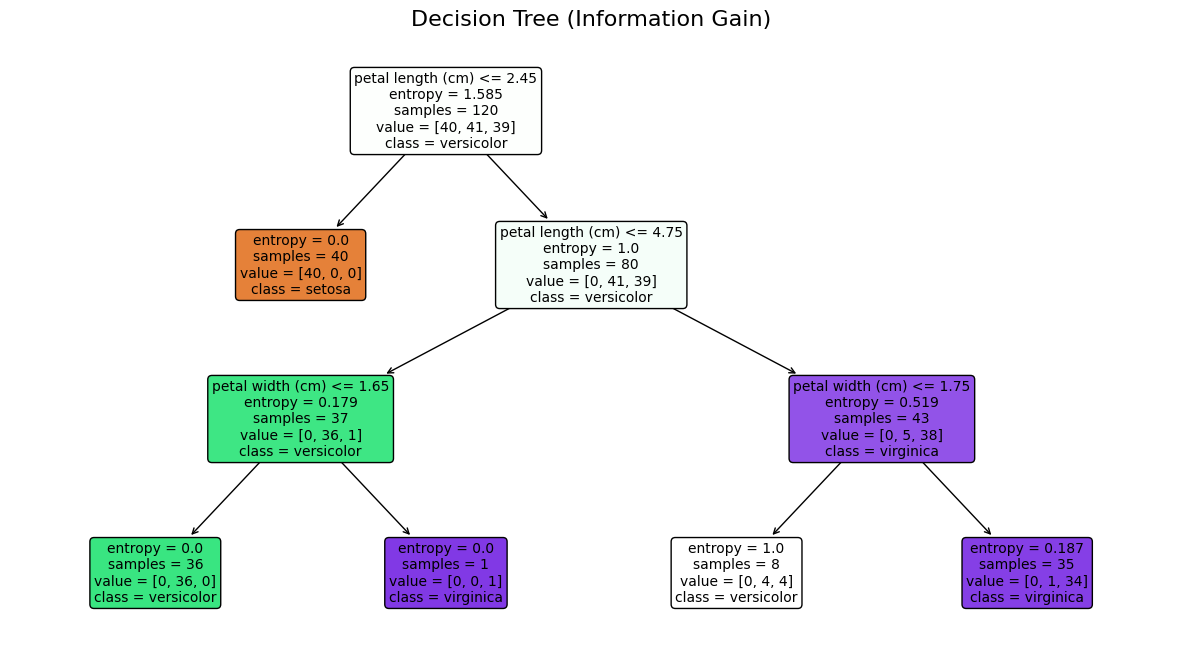

In [5]:
plt.figure(figsize=(15, 8))
plot_tree(dt_entropy, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,rounded=True,fontsize=10)
plt.title("Decision Tree (Information Gain)", fontsize=16)
plt.show()

In [6]:
# Gini Index 기준(criterion='gini')
dt_gini= DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_gini.fit(X_train, y_train)

# 예측및정확도계산
y_pred_gini= dt_gini.predict(X_test)
accuracy_gini= accuracy_score(y_test, y_pred_gini)
print("Gini Index 기준정확도:", round(accuracy_gini, 4))
print(f"({accuracy_gini*100:.2f}%)")

Gini Index 기준정확도: 1.0
(100.00%)


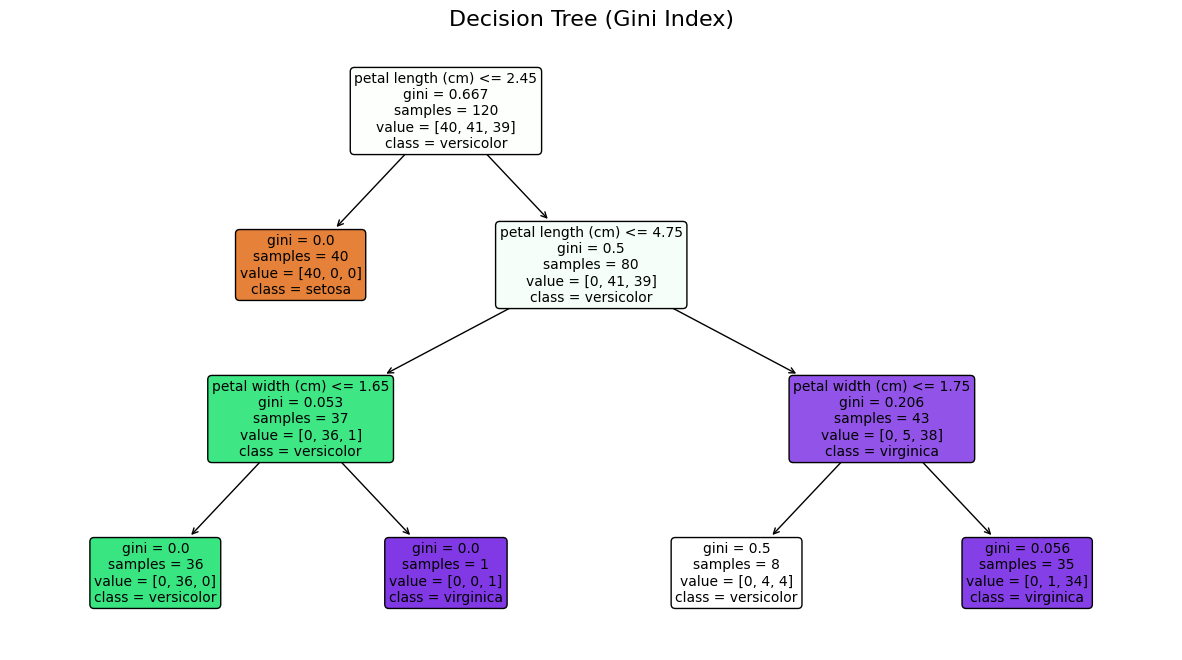

In [7]:
# 의사결정트리시각화(Gini Index)
plt.figure(figsize=(15, 8))
plot_tree(dt_gini, feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (Gini Index)', fontsize=16)
plt.show()

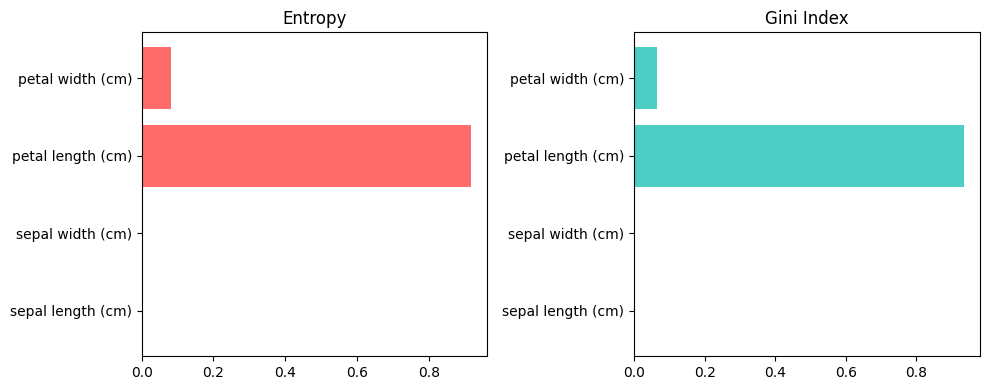

In [8]:
plt.figure(figsize=(10, 4))
# Information Gain
plt.subplot(1, 2, 1)
plt.barh(iris.feature_names, dt_entropy.feature_importances_, color='#FF6B6B')
plt.title('Entropy')
# Gini Index
plt.subplot(1, 2, 2)
plt.barh(iris.feature_names, dt_gini.feature_importances_, color='#4ECDC4')
plt.title('Gini Index')
plt.tight_layout()
plt.show()

In [9]:
# 1. Bootstrap Sampling 함수
def bootstrap_sample(X, y, random_state=None):
    np.random.seed(random_state)
    n_samples= len(X)
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return X[indices], y[indices]
# 2. Majority Voting 함수
def majority_vote(predictions):
    return mode(predictions, axis=1)[0].ravel()
# Bagging 구현
n_estimators= 100
max_depth= 3
bagging_models= []

In [10]:
# 각Bootstrap set으로Decision Tree 학습
for i in range(n_estimators):
    X_bootstrap, y_bootstrap= bootstrap_sample(X_train, y_train, random_state=42+i)
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42+i)
    tree.fit(X_bootstrap, y_bootstrap)
    bagging_models.append(tree)

all_predictions= np.array([model.predict(X_test) for model in bagging_models])
all_predictions= all_predictions.T
y_pred_bagging= majority_vote(all_predictions)

accuracy_bagging= accuracy_score(y_test, y_pred_bagging)
print("Bagging accuracy:", round(accuracy_bagging, 4))
print(f"({accuracy_bagging*100:.2f}%)")
print(f"Numberof trees: {n_estimators}")

Bagging accuracy: 1.0
(100.00%)
Numberof trees: 100


/var/folders/4b/vzqwkl_51dqf8yvvs86kd7kr0000gn/T/ipykernel_13811/1187002186.py:9: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  return mode(predictions, axis=1)[0].ravel()


In [11]:
ada_model= AdaBoostClassifier(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)
# 예측및정확도
y_pred_ada= ada_model.predict(X_test)
accuracy_ada= accuracy_score(y_test, y_pred_ada)
print("AdaBoost accuracy:", round(accuracy_ada, 4))
print(f"({accuracy_ada*100:.2f}%)")
print(f"Numberof estimators: {ada_model.n_estimators}")

AdaBoost accuracy: 1.0
(100.00%)
Numberof estimators: 50
